<a href="https://colab.research.google.com/github/rohit-khaire/AI-ML/blob/main/DS_Lab_NYC_Taxi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Science Lab — Unified Experiment Notebook
**Dataset:** NYC Yellow Taxi Trip Data (March 2016)  
**Experiments Covered:** EXP 1 → EXP 11  
**Pipeline Flow:** Dataset loading → Cleaning → Visualisation → Outlier removal → Scaling → Class balancing → Feature selection → Regression → Classification → Clustering → Big Data EDA (PySpark)

---
> **How to use this notebook:**  
> Run cells top-to-bottom in sequence. Each experiment is clearly sectioned and builds on the one before it.  
> The dataset (`yellow_tripdata_2016-03.csv`) is uploaded once at the top and reused throughout.


## 🔧 Global Imports & Setup
All required libraries are imported here so we don't repeat import blocks across experiments.

In [1]:
# Standard Data Handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Testing
from scipy import stats

# Preprocessing & Feature Engineering
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

# Machine Learning Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix
)
from sklearn.cluster import KMeans

# Class Imbalance Handling
from imblearn.over_sampling import SMOTE

print("All libraries loaded successfully.")

All libraries loaded successfully.


## 📂 Dataset Upload
Upload the raw CSV file (`yellow_tripdata_2016-03.csv`) using the cell below.  
The file picker will appear — select your CSV and it will be loaded automatically.

In [2]:
from google.colab import files

print("Please upload the dataset CSV file:")
uploaded = files.upload()

# Auto-detect the uploaded filename
filename = list(uploaded.keys())[0]
print(f"\nLoaded file: {filename}")

df_raw = pd.read_csv(filename)
print(f"Shape: {df_raw.shape}")
df_raw.head()

Please upload the dataset CSV file:


Saving yellow_tripdata_2016-03.csv to yellow_tripdata_2016-03.csv

Loaded file: yellow_tripdata_2016-03.csv
Shape: (500, 19)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,1,2016-03-01 00:00:00,2016-03-01 00:07:55,1,2.50,-73.976746,40.765152,1,N,-74.004265,40.746128,1,9.0,0.5,0.5,2.05,0.00,0.3,12.35
1,1,2016-03-01 00:00:00,2016-03-01 00:11:06,1,2.90,-73.983482,40.767925,1,N,-74.005943,40.733166,1,11.0,0.5,0.5,3.05,0.00,0.3,15.35
2,2,2016-03-01 00:00:00,2016-03-01 00:31:06,2,19.98,-73.782021,40.644810,1,N,-73.974541,40.675770,1,54.5,0.5,0.5,8.00,0.00,0.3,63.80
3,2,2016-03-01 00:00:00,2016-03-01 00:00:00,3,10.78,-73.863419,40.769814,1,N,-73.969650,40.757767,1,31.5,0.0,0.5,3.78,5.54,0.3,41.62
4,2,2016-03-01 00:00:00,2016-03-01 00:00:00,5,30.43,-73.971741,40.792183,3,N,-74.177170,40.695053,1,98.0,0.0,0.0,0.00,15.50,0.3,113.80


---
## Experiment 1 — Dataset Exploration, Missing Value Handling & Duplicate Removal

### Theory
Before any analysis, we must understand the raw data and ensure it is trustworthy.  
This involves three steps:

**1. Exploratory inspection** — shape, column names, data types, and basic statistics give us a mental model of the dataset.

**2. Missing value handling** — real-world datasets almost always have gaps. Two common strategies:
- **Median imputation** for numerical columns: the median is preferred over the mean because it is robust to skew and outliers. Taxi fare amounts, trip distances, and tip values tend to be right-skewed, making the median particularly appropriate.
- **Mode imputation** for categorical columns: filling with the most frequent category preserves the existing distribution.

**3. Duplicate removal** — duplicate rows artificially inflate counts, bias statistics, and can cause data leakage in ML splits. We identify and drop them before any further work.


In [3]:
# ── 1.1 Basic Inspection ──────────────────────────────────────────────────────
print("Shape (rows, columns):", df_raw.shape)
print("\nColumn names:", list(df_raw.columns))
print("\nData types:")
print(df_raw.dtypes)
print("\nSummary statistics:")
df_raw.describe()

Shape (rows, columns): (500, 19)

Column names: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'pickup_longitude', 'pickup_latitude', 'RatecodeID', 'store_and_fwd_flag', 'dropoff_longitude', 'dropoff_latitude', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount']

Data types:
VendorID                   int64
tpep_pickup_datetime      object
tpep_dropoff_datetime     object
passenger_count            int64
trip_distance            float64
pickup_longitude         float64
pickup_latitude          float64
RatecodeID                 int64
store_and_fwd_flag        object
dropoff_longitude        float64
dropoff_latitude         float64
payment_type               int64
fare_amount              float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amo

,VendorID,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,1.864000,1.810000,3.532520,-73.230487,40.343470,1.066000,-73.229710,40.343639,1.260000,13.420680,0.1640,0.494000,2.012300,0.419400,0.298200,16.808580
std,0.343132,1.486715,4.216213,7.367499,4.058868,0.349124,7.367429,4.058902,0.452559,12.143285,0.2371,0.063023,2.529849,1.716097,0.029976,15.050423
min,1.000000,1.000000,0.000000,-74.651306,0.000000,1.000000,-74.651306,0.000000,1.000000,-5.500000,0.0000,-0.500000,0.000000,0.000000,-0.300000,-6.300000
25%,2.000000,1.000000,1.100000,-73.990351,40.737923,1.000000,-73.988432,40.734112,1.000000,6.000000,0.0000,0.500000,0.000000,0.000000,0.300000,8.160000
50%,2.000000,1.000000,2.090000,-73.979557,40.755594,1.000000,-73.976116,40.756313,1.000000,9.500000,0.0000,0.500000,1.455000,0.000000,0.300000,11.780000
75%,2.000000,2.000000,3.855000,-73.959963,40.771248,1.000000,-73.956045,40.767567,2.000000,15.125000,0.5000,0.500000,2.382500,0.000000,0.300000,18.300000
max,2.000000,6.000000,30.430000,0.000000,40.845459,5.000000,0.000000,40.888912,3.000000,98.000000,1.0000,0.500000,16.360000,15.500000,0.300000,113.800000


In [4]:
# ── 1.2 Missing Value Check ───────────────────────────────────────────────────
print("Missing values per column:")
print(df_raw.isnull().sum())
print("\nMissing value percentage:")
print((df_raw.isnull().mean() * 100).round(2))

Missing values per column:
VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
pickup_longitude         0
pickup_latitude          0
RatecodeID               0
store_and_fwd_flag       0
dropoff_longitude        0
dropoff_latitude         0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
dtype: int64

Missing value percentage:
VendorID                 0.0
tpep_pickup_datetime     0.0
tpep_dropoff_datetime    0.0
passenger_count          0.0
trip_distance            0.0
pickup_longitude         0.0
pickup_latitude          0.0
RatecodeID               0.0
store_and_fwd_flag       0.0
dropoff_longitude        0.0
dropoff_latitude         0.0
payment_type             0.0
fare_amount              0.0
extra                    0.0
mta_tax       

In [5]:
# ── 1.3 Handle Missing Values ─────────────────────────────────────────────────
df = df_raw.copy()

# Numerical columns → fill with median (robust to right-skew in fare/distance data)
num_cols_with_na = df.select_dtypes(include=np.number).columns[df.select_dtypes(include=np.number).isnull().any()]
for col in num_cols_with_na:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical columns → fill with mode (most frequent category)
cat_cols_with_na = df.select_dtypes(include='object').columns[df.select_dtypes(include='object').isnull().any()]
for col in cat_cols_with_na:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
pickup_longitude         0
pickup_latitude          0
RatecodeID               0
store_and_fwd_flag       0
dropoff_longitude        0
dropoff_latitude         0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
dtype: int64


In [6]:
# ── 1.4 Duplicate Removal ─────────────────────────────────────────────────────
print("Duplicates found:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Shape after removing duplicates:", df.shape)
print("Duplicates remaining:", df.duplicated().sum())

# ── 1.5 Parse Datetime Features ───────────────────────────────────────────────
df['tpep_pickup_datetime']  = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# Engineer useful temporal features
df['trip_duration_min'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60
df['pickup_hour']       = df['tpep_pickup_datetime'].dt.hour
df['pickup_dayofweek']  = df['tpep_pickup_datetime'].dt.dayofweek   # 0=Mon … 6=Sun
df['pickup_day']        = df['tpep_pickup_datetime'].dt.day

# Remove negative or zero trip durations (data quality issue)
df = df[df['trip_duration_min'] > 0].copy()

# Save as the cleaned working copy
df_cleaned = df.copy()
print("\nCleaned dataset ready. Shape:", df_cleaned.shape)
df_cleaned.head()

Duplicates found: 0
Shape after removing duplicates: (500, 19)
Duplicates remaining: 0

Cleaned dataset ready. Shape: (496, 23)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,trip_duration_min,pickup_hour,pickup_dayofweek,pickup_day
0,1,2016-03-01 00:00:00,2016-03-01 00:07:55,1,2.50,-73.976746,40.765152,1,N,-74.004265,...,0.5,0.5,2.05,0.0,0.3,12.35,7.916667,0,1,1
1,1,2016-03-01 00:00:00,2016-03-01 00:11:06,1,2.90,-73.983482,40.767925,1,N,-74.005943,...,0.5,0.5,3.05,0.0,0.3,15.35,11.100000,0,1,1
2,2,2016-03-01 00:00:00,2016-03-01 00:31:06,2,19.98,-73.782021,40.644810,1,N,-73.974541,...,0.5,0.5,8.00,0.0,0.3,63.80,31.100000,0,1,1
7,1,2016-03-01 00:00:01,2016-03-01 00:16:04,1,6.20,-73.788773,40.647758,1,N,-73.829208,...,0.5,0.5,0.00,0.0,0.3,21.80,16.050000,0,1,1
8,1,2016-03-01 00:00:01,2016-03-01 00:05:00,1,0.70,-73.958221,40.764641,1,N,-73.967896,...,0.5,0.5,2.00,0.0,0.3,8.80,4.983333,0,1,1


---
## Experiment 2 — Data Visualisation

### Theory
Visualisation translates raw numbers into patterns the human eye can quickly interpret.  
We use several plot types here, each suited to a different question:

| Plot Type | Best Used For |
|-----------|--------------|
| **Histogram + KDE** | Understand how a single numerical variable is distributed |
| **Boxplot** | Spot the median, spread (IQR), and potential outliers at a glance |
| **Bar / Count plot** | Compare frequencies across categories (e.g., payment type, vendor) |
| **Scatter plot** | Examine the relationship between two numerical variables (e.g., distance vs fare) |
| **Correlation heatmap** | Summarise all pairwise linear relationships in one view; values close to ±1 indicate strong associations |

A triangular (masked) heatmap removes the redundant upper half so the chart is easier to read.


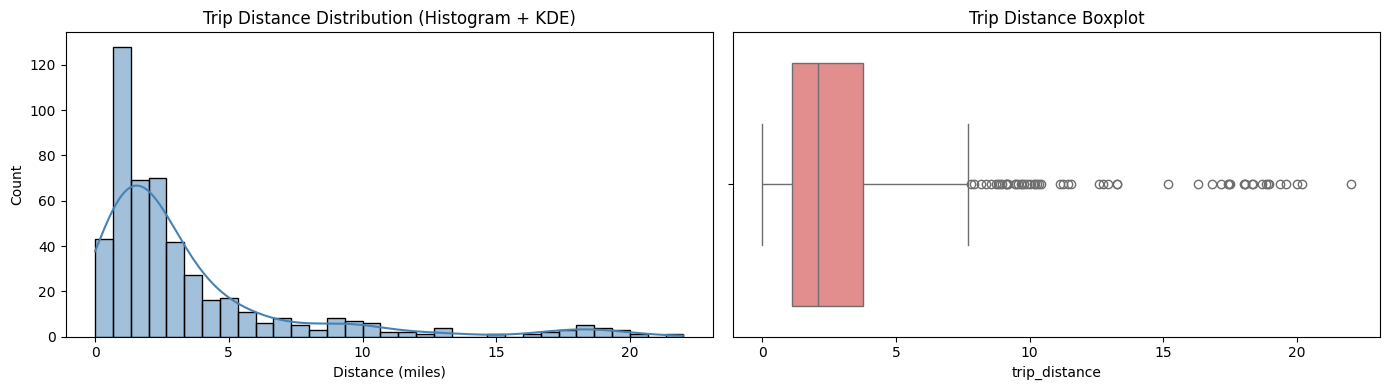

In [7]:
# ── 2.1 Trip Distance Distribution ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df_cleaned['trip_distance'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title("Trip Distance Distribution (Histogram + KDE)")
axes[0].set_xlabel("Distance (miles)")

sns.boxplot(x=df_cleaned['trip_distance'], ax=axes[1], color='lightcoral')
axes[1].set_title("Trip Distance Boxplot")

plt.tight_layout()
plt.show()

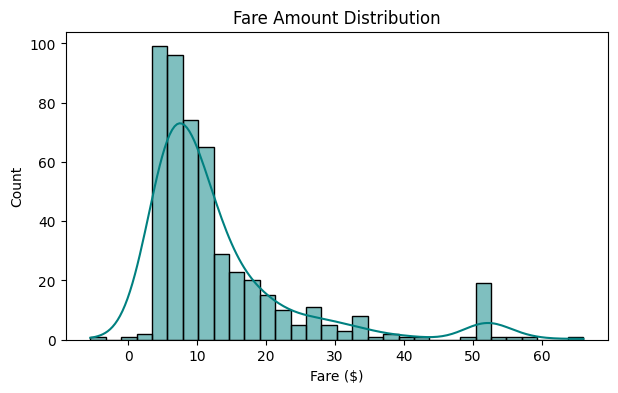

In [8]:
# ── 2.2 Fare Amount Distribution ─────────────────────────────────────────────
plt.figure(figsize=(7, 4))
sns.histplot(df_cleaned['fare_amount'], kde=True, color='teal')
plt.title("Fare Amount Distribution")
plt.xlabel("Fare ($)")
plt.show()

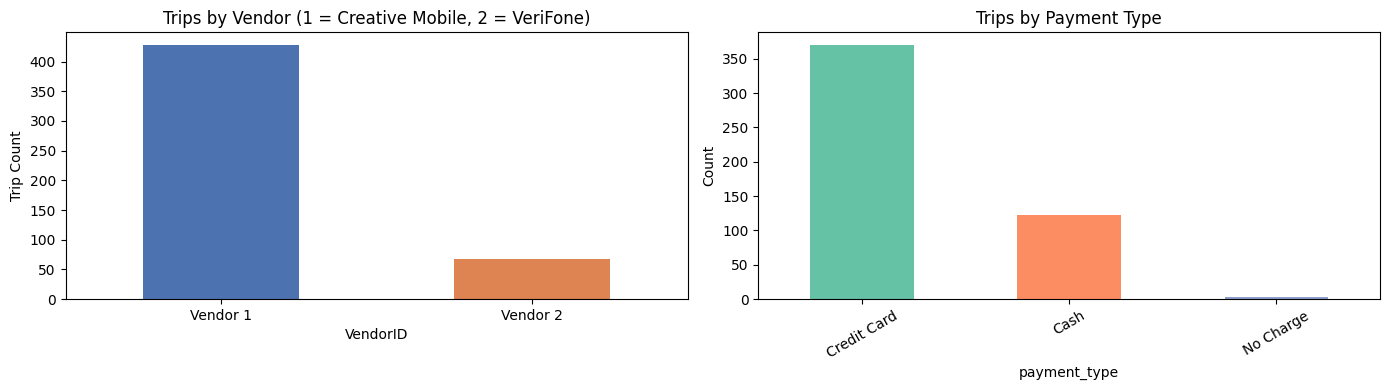

In [9]:
# ── 2.3 Vendor & Payment Type Distributions ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_cleaned['VendorID'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0','#DD8452'])
axes[0].set_title("Trips by Vendor (1 = Creative Mobile, 2 = VeriFone)")
axes[0].set_ylabel("Trip Count")
axes[0].set_xticklabels(['Vendor 1', 'Vendor 2'], rotation=0)

payment_labels = {1:'Credit Card', 2:'Cash', 3:'No Charge', 4:'Dispute', 5:'Unknown', 6:'Voided'}
df_cleaned['payment_type'].map(payment_labels).value_counts().plot(
    kind='bar', ax=axes[1], color=sns.color_palette("Set2"))
axes[1].set_title("Trips by Payment Type")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

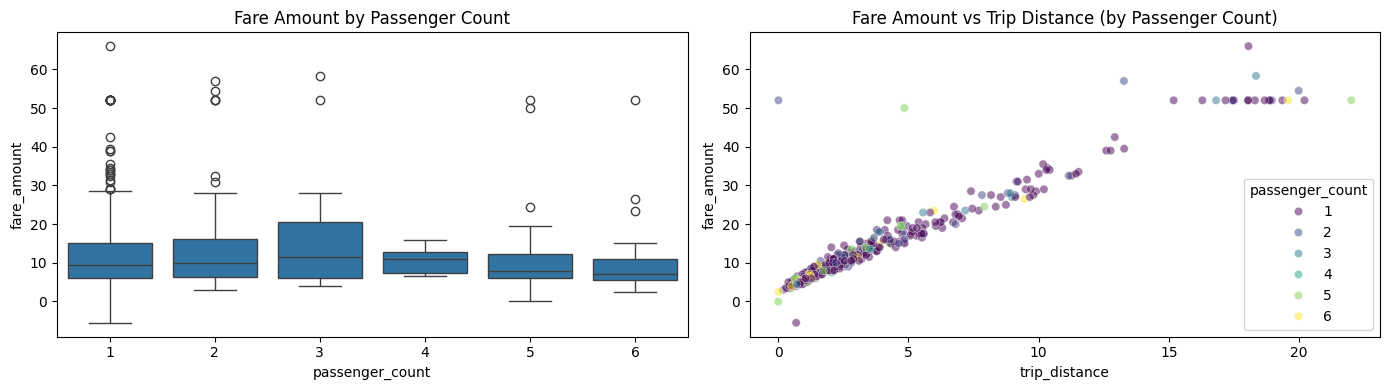

In [10]:
# ── 2.4 Fare & Tip by Passenger Count ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(x='passenger_count', y='fare_amount', data=df_cleaned, ax=axes[0])
axes[0].set_title("Fare Amount by Passenger Count")

sns.scatterplot(x='trip_distance', y='fare_amount',
                hue='passenger_count', data=df_cleaned, alpha=0.5, ax=axes[1],
                palette='viridis')
axes[1].set_title("Fare Amount vs Trip Distance (by Passenger Count)")

plt.tight_layout()
plt.show()

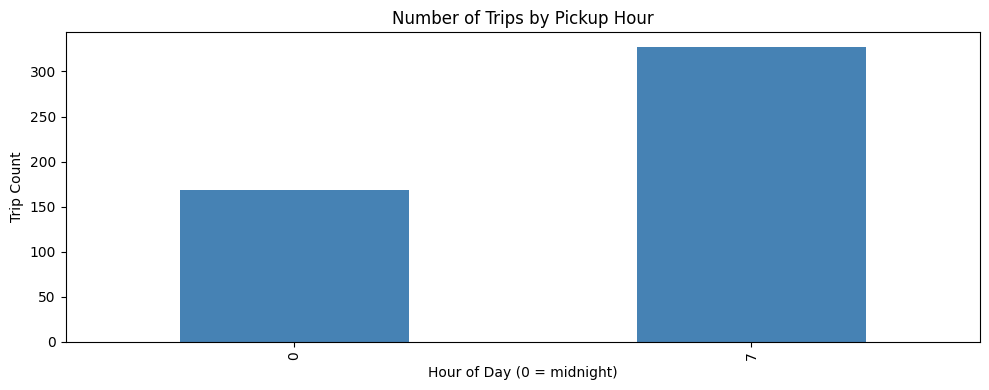

In [11]:
# ── 2.5 Trips by Hour of Day ──────────────────────────────────────────────────
plt.figure(figsize=(10, 4))
df_cleaned['pickup_hour'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title("Number of Trips by Pickup Hour")
plt.xlabel("Hour of Day (0 = midnight)")
plt.ylabel("Trip Count")
plt.tight_layout()
plt.show()

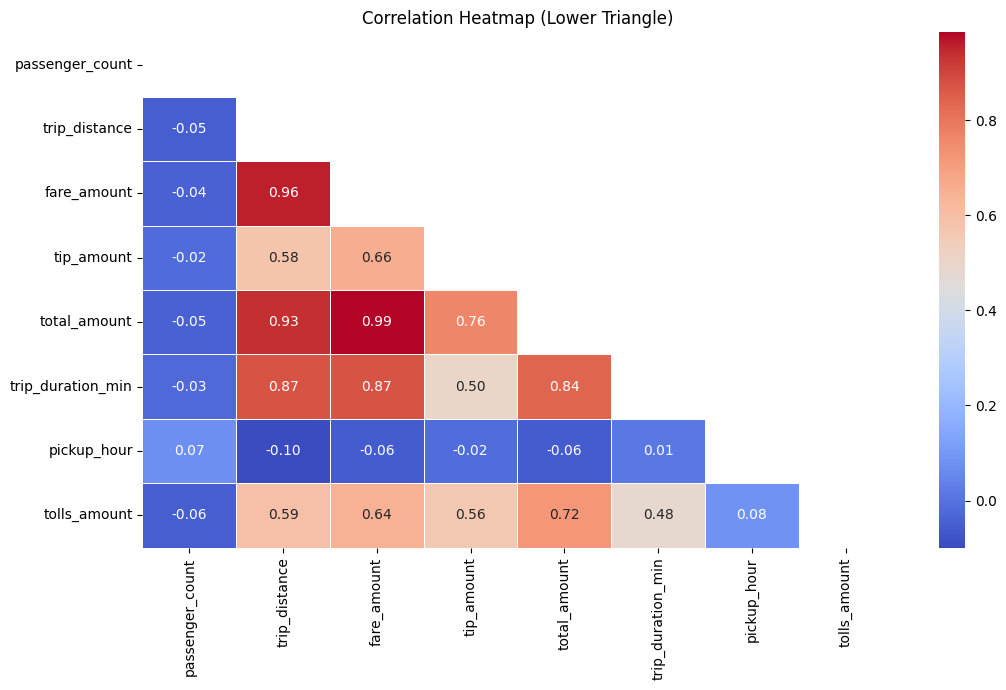

In [12]:
# ── 2.6 Correlation Heatmap (Triangular) ─────────────────────────────────────
numeric_cols_all = ['passenger_count','trip_distance','fare_amount','tip_amount',
                    'total_amount','trip_duration_min','pickup_hour','tolls_amount']
corr = df_cleaned[numeric_cols_all].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))   # hide upper triangle

plt.figure(figsize=(11, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap='coolwarm', linewidths=0.4)
plt.title("Correlation Heatmap (Lower Triangle)")
plt.tight_layout()
plt.show()

---
## Experiment 3 — Outlier Detection & Removal

### Theory
Outliers are data points that deviate far from the rest of the distribution. They can:
- Distort means and standard deviations
- Violate assumptions of linear models
- Inflate error metrics like MSE

In a taxi dataset, outliers commonly appear as:
- Trips with `fare_amount` ≤ 0 (refunds, errors) or extremely large values
- `trip_distance` of 0 (cancelled rides) or implausibly large
- Negative `tip_amount`

We apply two complementary techniques:

**IQR Method (Interquartile Range)**  
The IQR = Q3 − Q1 spans the middle 50% of data.  
Any value outside [Q1 − 1.5·IQR,  Q3 + 1.5·IQR] is flagged as an outlier.  
This method is non-parametric — it makes no assumption about the underlying distribution.

**Z-Score Method**  
Z = (x − μ) / σ measures how many standard deviations a point is from the mean.  
Values with |Z| > 3 are treated as outliers (covers 99.7% of normally distributed data).  
This method is sensitive to the distribution shape but very fast to compute.

We use IQR removal as our final cleaning step and save the result for downstream experiments.


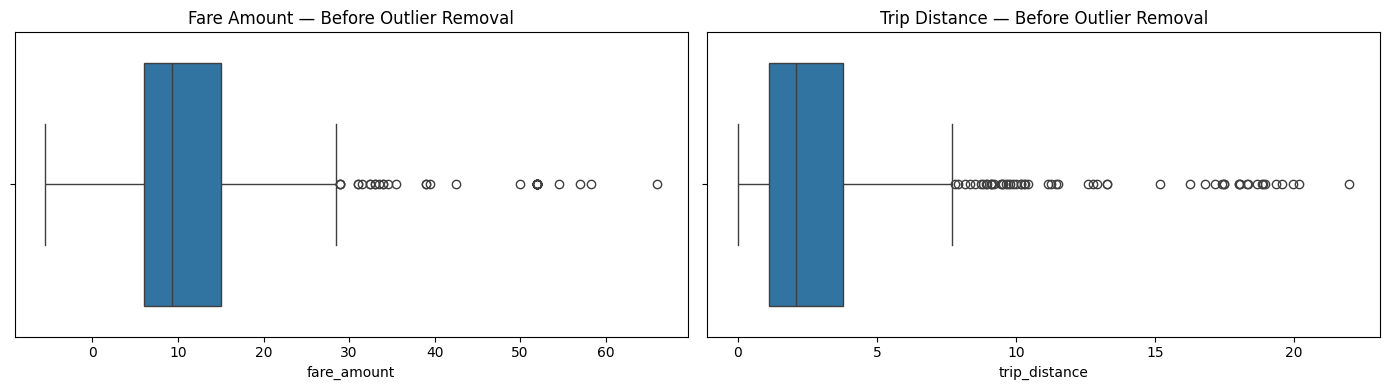

In [13]:
# ── 3.1 Visual Inspection — Before Removal ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(x=df_cleaned['fare_amount'], ax=axes[0])
axes[0].set_title("Fare Amount — Before Outlier Removal")
sns.boxplot(x=df_cleaned['trip_distance'], ax=axes[1])
axes[1].set_title("Trip Distance — Before Outlier Removal")
plt.tight_layout()
plt.show()

In [14]:
# ── 3.2 IQR Method on fare_amount ────────────────────────────────────────────
Q1 = df_cleaned['fare_amount'].quantile(0.25)
Q3 = df_cleaned['fare_amount'].quantile(0.75)
IQR = Q3 - Q1

lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR

print(f"Q1 = {Q1:.2f}  |  Q3 = {Q3:.2f}  |  IQR = {IQR:.2f}")
print(f"Allowed range (IQR): [{lower_iqr:.2f},  {upper_iqr:.2f}]")
print(f"Outliers flagged: {((df_cleaned['fare_amount'] < lower_iqr) | (df_cleaned['fare_amount'] > upper_iqr)).sum()}")

df_no_outliers = df_cleaned[
    (df_cleaned['fare_amount'] >= lower_iqr) & (df_cleaned['fare_amount'] <= upper_iqr)
].copy()
print(f"Shape after IQR removal: {df_no_outliers.shape}")

Q1 = 6.00  |  Q3 = 15.00  |  IQR = 9.00
Allowed range (IQR): [-7.50,  28.50]
Outliers flagged: 43
Shape after IQR removal: (453, 23)


In [15]:
# ── 3.3 Z-Score Method on fare_amount (for comparison) ───────────────────────
z_upper = df_cleaned['fare_amount'].mean() + 3 * df_cleaned['fare_amount'].std()
z_lower = df_cleaned['fare_amount'].mean() - 3 * df_cleaned['fare_amount'].std()

print(f"Z-Score method allowed range: [{z_lower:.2f},  {z_upper:.2f}]")
outliers_z = df_cleaned[(df_cleaned['fare_amount'] > z_upper) | (df_cleaned['fare_amount'] < z_lower)]
print(f"Outliers by Z-Score: {len(outliers_z)}")

Z-Score method allowed range: [-21.43,  47.78]
Outliers by Z-Score: 24


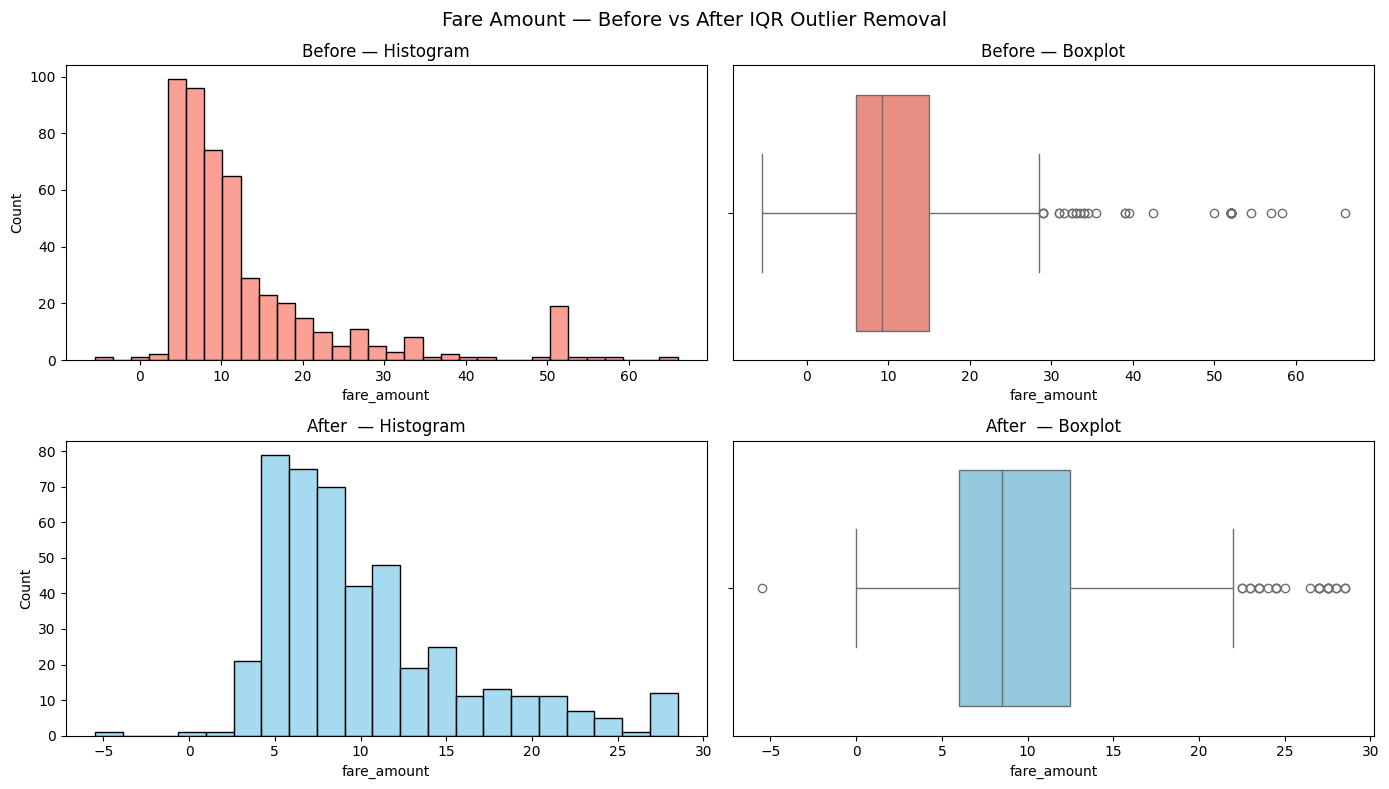

In [16]:
# ── 3.4 Before vs After Comparison ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Fare Amount — Before vs After IQR Outlier Removal", fontsize=14)

sns.histplot(df_cleaned['fare_amount'],    ax=axes[0, 0], color='salmon');  axes[0,0].set_title("Before — Histogram")
sns.boxplot(x=df_cleaned['fare_amount'],   ax=axes[0, 1], color='salmon');  axes[0,1].set_title("Before — Boxplot")
sns.histplot(df_no_outliers['fare_amount'], ax=axes[1, 0], color='skyblue'); axes[1,0].set_title("After  — Histogram")
sns.boxplot(x=df_no_outliers['fare_amount'],ax=axes[1, 1], color='skyblue'); axes[1,1].set_title("After  — Boxplot")

plt.tight_layout()
plt.show()

In [17]:
# Save the cleaned (outlier-removed) dataset for all subsequent experiments
df_clean = df_no_outliers.copy()
print("Outlier-free dataset shape:", df_clean.shape)

Outlier-free dataset shape: (453, 23)


---
## Experiment 4 — Feature Scaling (Normalisation & Standardisation)

### Theory
Most ML algorithms are sensitive to the magnitude of feature values.  
Without scaling, features with larger numeric ranges (e.g., `fare_amount` 0–100) dominate those with smaller ranges (e.g., `passenger_count` 1–6), distorting distance-based and gradient-based methods.

**Min-Max Normalisation**  
Maps each value to [0, 1]:  
`x_norm = (x − x_min) / (x_max − x_min)`  
Best when you need values in a bounded range (e.g., neural networks, KNN).

**Z-Score Standardisation**  
Centers data to mean=0 and std=1:  
`x_std = (x − μ) / σ`  
Best when the algorithm assumes a Gaussian distribution (e.g., linear/logistic regression, SVM, PCA).

We apply both to the key numerical columns and compare the resulting statistics.


In [18]:
numeric_cols = ['trip_distance', 'fare_amount', 'tip_amount', 'total_amount', 'trip_duration_min']

print("Original statistics:")
df_clean[numeric_cols].describe().round(3)

Original statistics:


,trip_distance,fare_amount,tip_amount,total_amount,trip_duration_min
count,453.000,453.000,453.000,453.000,453.000
mean,2.439,10.193,1.567,12.819,10.185
std,1.968,5.764,1.527,7.048,6.364
min,0.000,-5.500,0.000,-6.300,0.050
25%,1.060,6.000,0.000,7.800,5.333
50%,1.840,8.500,1.360,11.160,8.450
75%,3.100,12.500,2.080,15.350,13.650
max,9.900,28.500,10.300,44.640,35.267


In [19]:
# ── 4.1 Min-Max Normalisation ─────────────────────────────────────────────────
minmax = MinMaxScaler()
df_norm = df_clean.copy()
df_norm[numeric_cols] = minmax.fit_transform(df_clean[numeric_cols])

print("After Min-Max Normalisation (all values should be in [0, 1]):")
df_norm[numeric_cols].describe().round(3)

After Min-Max Normalisation (all values should be in [0, 1]):


,trip_distance,fare_amount,tip_amount,total_amount,trip_duration_min
count,453.000,453.000,453.000,453.000,453.000
mean,0.246,0.462,0.152,0.375,0.288
std,0.199,0.170,0.148,0.138,0.181
min,0.000,0.000,0.000,0.000,0.000
25%,0.107,0.338,0.000,0.277,0.150
50%,0.186,0.412,0.132,0.343,0.239
75%,0.313,0.529,0.202,0.425,0.386
max,1.000,1.000,1.000,1.000,1.000


In [20]:
# ── 4.2 Z-Score Standardisation ──────────────────────────────────────────────
scaler = StandardScaler()
df_std = df_clean.copy()
df_std[numeric_cols] = scaler.fit_transform(df_clean[numeric_cols])

print("After Z-Score Standardisation (mean ≈ 0, std ≈ 1):")
df_std[numeric_cols].describe().round(3)

After Z-Score Standardisation (mean ≈ 0, std ≈ 1):


,trip_distance,fare_amount,tip_amount,total_amount,trip_duration_min
count,453.000,453.000,453.000,453.000,453.000
mean,0.000,-0.000,0.000,0.000,0.000
std,1.001,1.001,1.001,1.001,1.001
min,-1.241,-2.725,-1.027,-2.716,-1.594
25%,-0.702,-0.728,-1.027,-0.713,-0.763
50%,-0.305,-0.294,-0.136,-0.236,-0.273
75%,0.336,0.401,0.337,0.360,0.545
max,3.796,3.179,5.726,4.520,3.946


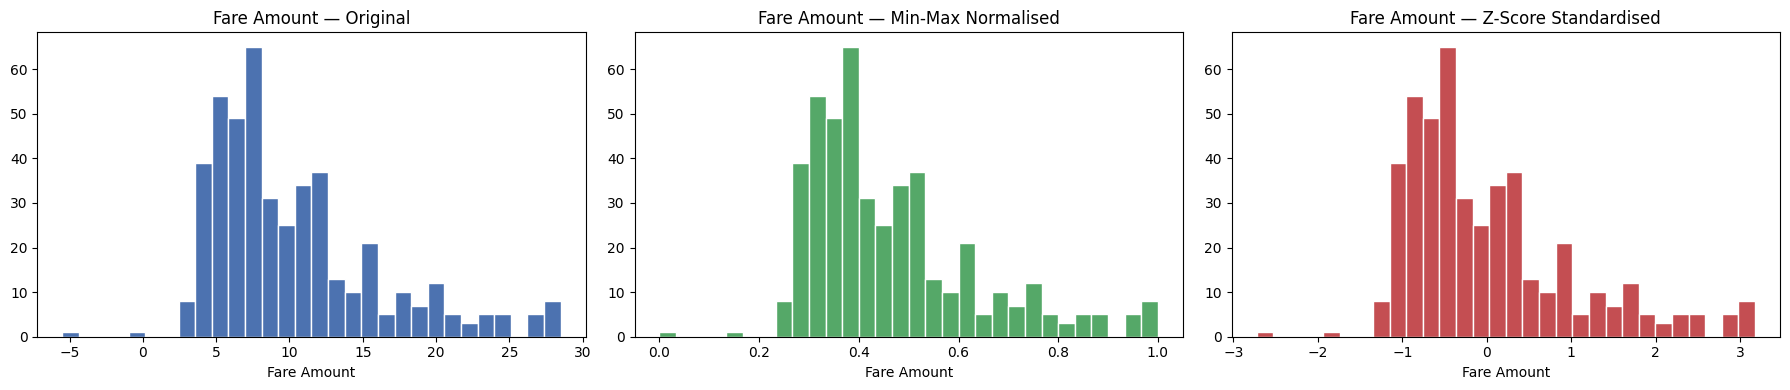

In [21]:
# ── 4.3 Visual Comparison ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, data, label, color in zip(
    axes,
    [df_clean, df_norm, df_std],
    ['Original', 'Min-Max Normalised', 'Z-Score Standardised'],
    ['#4C72B0', '#55A868', '#C44E52']
):
    ax.hist(data['fare_amount'], bins=30, color=color, edgecolor='white')
    ax.set_title(f"Fare Amount — {label}")
    ax.set_xlabel("Fare Amount")

plt.tight_layout()
plt.show()

---
## Experiment 5 — Class Imbalance Handling with SMOTE

### Theory
In classification tasks, if one class appears far more often than another, the model learns to predict the majority class almost exclusively — achieving high raw accuracy but completely failing on the minority class.

**SMOTE — Synthetic Minority Over-sampling Technique**  
Rather than simply duplicating minority class rows (which causes overfitting), SMOTE generates *synthetic* new samples by interpolating between existing minority class neighbours in feature space.  
For each minority sample, it selects k nearest neighbours and creates new points along the line segments connecting them.

**Why this matters here:**  
We predict whether a trip was paid by **credit card (1) or cash (2)** — a binary classification.  
Credit card and cash payments may be imbalanced in the dataset.  
Applying SMOTE before model training ensures the classifier is not biased toward the dominant payment type.


In [22]:
# ── 5.1 Prepare Features ──────────────────────────────────────────────────────
df_smote = df_clean.copy()

# Keep only credit card (1) and cash (2) — binary classification
df_smote = df_smote[df_smote['payment_type'].isin([1, 2])].copy()
# Recode: credit card = 1, cash = 0
df_smote['payment_binary'] = (df_smote['payment_type'] == 1).astype(int)

feature_cols = ['trip_distance', 'fare_amount', 'tip_amount',
                'passenger_count', 'trip_duration_min', 'pickup_hour']

X = df_smote[feature_cols]
y = df_smote['payment_binary']

print("Class distribution before SMOTE:")
print(y.value_counts())
print(f"\nFeature matrix shape: {X.shape}")

Class distribution before SMOTE:
payment_binary
1    339
0    111
Name: count, dtype: int64

Feature matrix shape: (450, 6)


In [23]:
# ── 5.2 Train-Test Split ──────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)
print("Training set shape:", X_train.shape)
print("Testing set shape: ", X_test.shape)

Training set shape: (315, 6)
Testing set shape:  (135, 6)


In [24]:
# ── 5.3 Apply SMOTE ───────────────────────────────────────────────────────────
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

print("Before SMOTE — X_train:", X_train.shape, "  y_train:", y_train.shape)
print("After  SMOTE — X_res:  ", X_res.shape,   "  y_res:  ", y_res.shape)
print("\nClass distribution after SMOTE:")
print(pd.Series(y_res).value_counts())

Before SMOTE — X_train: (315, 6)   y_train: (315,)
After  SMOTE — X_res:   (476, 6)   y_res:   (476,)

Class distribution after SMOTE:
payment_binary
1    238
0    238
Name: count, dtype: int64


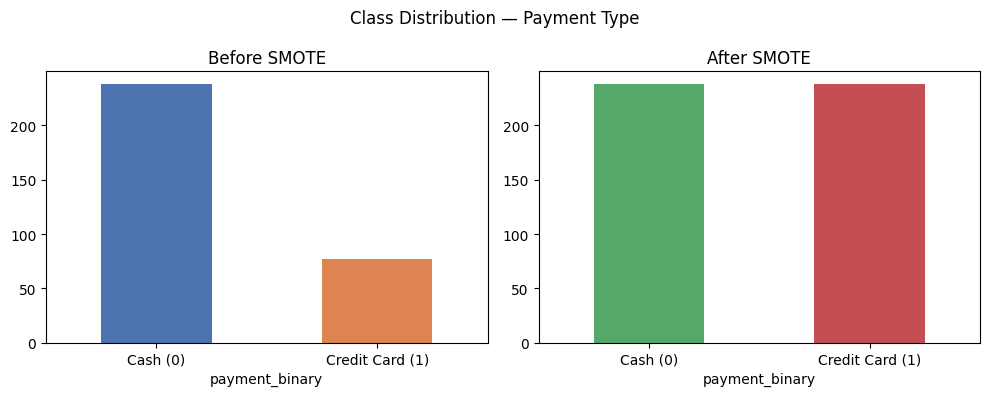

In [25]:
# ── 5.4 Visualise Balance ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

y_train.value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0','#DD8452'])
axes[0].set_title("Before SMOTE")
axes[0].set_xticklabels(['Cash (0)', 'Credit Card (1)'], rotation=0)

pd.Series(y_res).value_counts().plot(kind='bar', ax=axes[1], color=['#55A868','#C44E52'])
axes[1].set_title("After SMOTE")
axes[1].set_xticklabels(['Cash (0)', 'Credit Card (1)'], rotation=0)

plt.suptitle("Class Distribution — Payment Type")
plt.tight_layout()
plt.show()

---
## Experiment 6 — Feature Selection & Linear Regression

### Theory
**Feature Selection**  
Using every column in a dataset does not always improve a model. Irrelevant or redundant features add noise, inflate training time, and can hurt generalisation.  
Here we use all available numerical features as a baseline and rely on Linear Regression's coefficients to reveal which features the model leans on most.

**Linear Regression**  
Assumes a linear relationship between features X and a continuous target y:  
`ŷ = β₀ + β₁x₁ + β₂x₂ + …`  
The coefficients β are estimated by minimising the Residual Sum of Squares.

**Evaluation Metrics**  
- **R² (coefficient of determination):** Proportion of variance in y explained by the model. Ranges from 0 to 1; higher is better.  
- **MSE (Mean Squared Error):** Average of squared prediction errors. Penalises large errors heavily; lower is better.

In this experiment we predict **`total_amount`** (the full trip cost) from all other numerical features.


In [26]:
# ── 6.1 Prepare Data ──────────────────────────────────────────────────────────
df6 = df_clean.copy()
feature_cols6 = ['trip_distance', 'fare_amount', 'tip_amount', 'tolls_amount',
                 'passenger_count', 'trip_duration_min', 'pickup_hour', 'extra',
                 'mta_tax', 'improvement_surcharge']

X6 = df6[feature_cols6]
y6 = df6['total_amount']

X6_train, X6_test, y6_train, y6_test = train_test_split(
    X6, y6, test_size=0.2, random_state=42
)

sc6 = StandardScaler()
X6_train_sc = sc6.fit_transform(X6_train)
X6_test_sc  = sc6.transform(X6_test)

print("Training samples:", X6_train.shape[0], "| Test samples:", X6_test.shape[0])

Training samples: 362 | Test samples: 91


In [27]:
# ── 6.2 Train & Evaluate ──────────────────────────────────────────────────────
lr = LinearRegression()
lr.fit(X6_train_sc, y6_train)
y6_pred = lr.predict(X6_test_sc)

print(f"R²  Score : {r2_score(y6_test, y6_pred):.4f}")
print(f"MSE       : {mean_squared_error(y6_test, y6_pred):.4f}")

R²  Score : 1.0000
MSE       : 0.0000


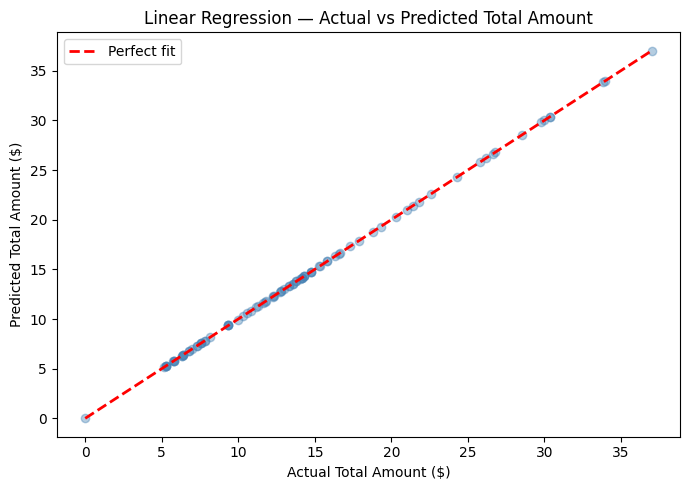

In [28]:
# ── 6.3 Actual vs Predicted Plot ──────────────────────────────────────────────
plt.figure(figsize=(7, 5))
plt.scatter(y6_test, y6_pred, alpha=0.4, color='steelblue')
plt.plot([y6_test.min(), y6_test.max()],
         [y6_test.min(), y6_test.max()], 'r--', lw=2, label="Perfect fit")
plt.xlabel("Actual Total Amount ($)")
plt.ylabel("Predicted Total Amount ($)")
plt.title("Linear Regression — Actual vs Predicted Total Amount")
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_2190/1077419403.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='coolwarm')


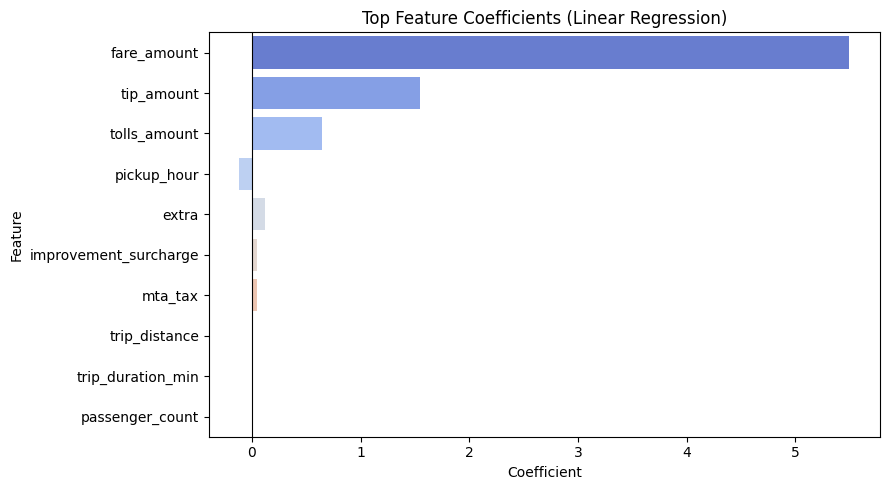

In [29]:
# ── 6.4 Top Feature Coefficients ─────────────────────────────────────────────
coef_df = pd.DataFrame({
    'Feature': feature_cols6,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False).head(10)

plt.figure(figsize=(9, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='coolwarm')
plt.title("Top Feature Coefficients (Linear Regression)")
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

---
## Experiment 7 — Hypothesis Testing (Independent Samples T-Test)

### Theory
A hypothesis test gives us a principled, statistical way to answer questions like:  
*"Is the difference I observe between two groups real, or just due to random chance?"*

**Independent Samples T-Test**  
Compares the means of two independent, continuous groups to assess if they differ significantly.

- **H₀ (Null Hypothesis):** Mean fare amount paid by Credit Card = Mean fare amount paid by Cash  
- **H₁ (Alternative Hypothesis):** Mean fare amounts differ between payment types  

The test returns:
- **T-statistic:** Magnitude of the difference relative to variability
- **P-value:** Probability of observing this result if H₀ were true

**Decision rule:** If p-value < α (0.05), reject H₀ — the difference is statistically significant.  
If p-value ≥ α, we fail to reject H₀ — not enough evidence to claim a difference.


In [30]:
# ── 7.1 Group Means ───────────────────────────────────────────────────────────
card_fares = df_clean[df_clean['payment_type'] == 1]['fare_amount']
cash_fares  = df_clean[df_clean['payment_type'] == 2]['fare_amount']

print(f"Credit Card — Mean: {card_fares.mean():.3f},  Std: {card_fares.std():.3f},  n: {len(card_fares)}")
print(f"Cash        — Mean: {cash_fares.mean():.3f},  Std: {cash_fares.std():.3f},  n: {len(cash_fares)}")

Credit Card — Mean: 10.292,  Std: 5.579,  n: 339
Cash        — Mean: 9.968,  Std: 6.126,  n: 111


In [31]:
# ── 7.2 T-Test ────────────────────────────────────────────────────────────────
t_stat, p_value = stats.ttest_ind(card_fares, cash_fares)
alpha = 0.05

print(f"T-statistic : {t_stat:.5f}")
print(f"P-value     : {p_value:.5f}")
print(f"Alpha       : {alpha}")

if p_value < alpha:
    print("\nConclusion: Reject H₀ → Statistically significant difference in fare amount by payment type.")
else:
    print("\nConclusion: Fail to Reject H₀ → No statistically significant difference in fare amount by payment type.")

T-statistic : 0.51746
P-value     : 0.60509
Alpha       : 0.05

Conclusion: Fail to Reject H₀ → No statistically significant difference in fare amount by payment type.


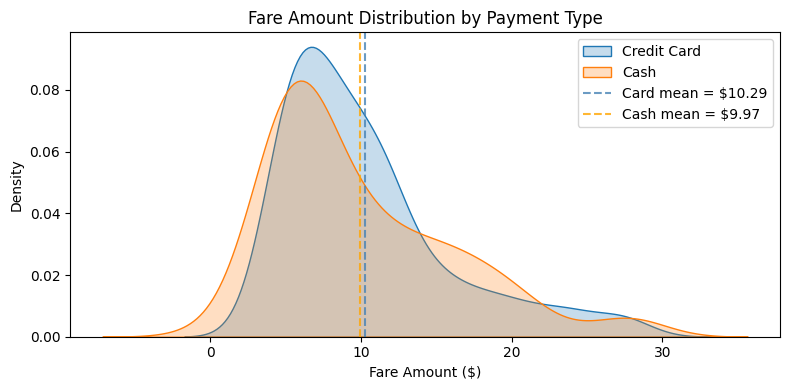

In [32]:
# ── 7.3 Visualise Distributions ───────────────────────────────────────────────
plt.figure(figsize=(8, 4))
sns.kdeplot(card_fares, label='Credit Card', fill=True)
sns.kdeplot(cash_fares,  label='Cash',        fill=True)
plt.axvline(card_fares.mean(), color='steelblue', linestyle='--', alpha=0.8,
            label=f"Card mean = ${card_fares.mean():.2f}")
plt.axvline(cash_fares.mean(),  color='orange',    linestyle='--', alpha=0.8,
            label=f"Cash mean = ${cash_fares.mean():.2f}")
plt.title("Fare Amount Distribution by Payment Type")
plt.xlabel("Fare Amount ($)")
plt.legend()
plt.tight_layout()
plt.show()

---
## Experiment 8 — Simple Linear Regression (Distance & Duration → Fare)

### Theory
While EXP 6 used all available features, here we focus on a **simple, interpretable two-feature model** to clearly understand the individual contribution of trip distance and duration to the fare.

**Why only two features?**  
Using only `trip_distance` and `trip_duration_min` lets us visualise the model's behaviour and understand exactly how each variable moves the predicted fare — something that gets lost in a 10+ feature model.

This experiment also reinforces the idea that a well-chosen small feature set can be surprisingly competitive with the full model.


In [33]:
# ── 8.1 Feature Selection & Split ────────────────────────────────────────────
X8 = df_clean[['trip_distance', 'trip_duration_min']]
y8 = df_clean['fare_amount']

X8_train, X8_test, y8_train, y8_test = train_test_split(
    X8, y8, test_size=0.2, random_state=42
)
print("Train / Test sizes:", X8_train.shape[0], "/", X8_test.shape[0])

Train / Test sizes: 362 / 91


In [34]:
# ── 8.2 Train & Evaluate ──────────────────────────────────────────────────────
model8 = LinearRegression()
model8.fit(X8_train, y8_train)
y8_pred = model8.predict(X8_test)

print(f"Coefficients:")
for feat, coef in zip(X8.columns, model8.coef_):
    print(f"  {feat}: {coef:.4f}")
print(f"Intercept : {model8.intercept_:.4f}")
print(f"\nMSE      : {mean_squared_error(y8_test, y8_pred):.4f}")
print(f"R² Score : {r2_score(y8_test, y8_pred):.4f}")

Coefficients:
  trip_distance: 1.9598
  trip_duration_min: 0.3290
Intercept : 2.0606

MSE      : 0.1963
R² Score : 0.9954


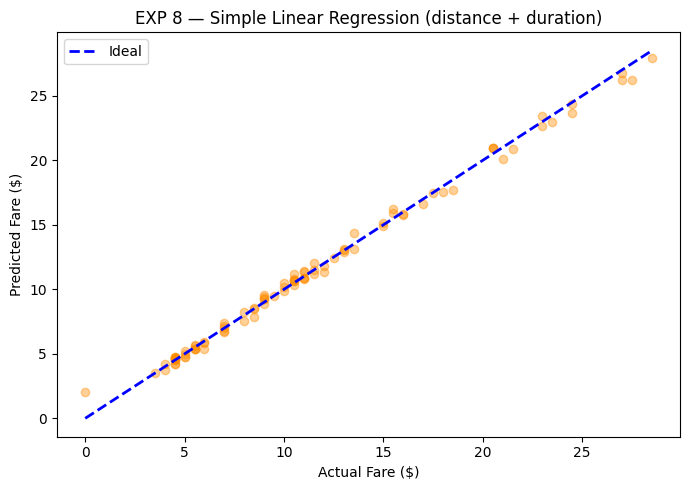

In [35]:
# ── 8.3 Predicted vs Actual ───────────────────────────────────────────────────
plt.figure(figsize=(7, 5))
plt.scatter(y8_test, y8_pred, alpha=0.4, color='darkorange')
plt.plot([y8_test.min(), y8_test.max()],
         [y8_test.min(), y8_test.max()], 'b--', lw=2, label="Ideal")
plt.xlabel("Actual Fare ($)")
plt.ylabel("Predicted Fare ($)")
plt.title("EXP 8 — Simple Linear Regression (distance + duration)")
plt.legend()
plt.tight_layout()
plt.show()

---
## Experiment 9 — Logistic Regression (Binary Classification)

### Theory
Fare amount is a continuous variable. But operators often need a binary answer: *"Was this a high-value trip or a low-value trip?"*  
We convert this into a classification problem by creating a threshold-based label.

**Target variable:**  
`high_fare = 1` if `fare_amount` ≥ median fare (High value trip), else `0` (Standard trip)

**Logistic Regression**  
Estimates the probability that a sample belongs to class 1 using the sigmoid function:  
`P(y=1) = 1 / (1 + e^(−(β₀ + β₁x₁ + …)))`  
Output probabilities are then thresholded at 0.5 to produce class labels.

**Evaluation Metrics**  
- **Accuracy:** Overall fraction correctly classified  
- **Precision:** Of all predicted high-fare trips, how many were truly high-fare?  
- **Recall:** Of all actual high-fare trips, how many did the model catch?  
- **F1-Score:** Harmonic mean of precision and recall — balances both concerns  
- **Confusion Matrix:** 2×2 table showing TP, FP, FN, TN counts  

`class_weight='balanced'` is used to handle any remaining imbalance after the threshold split.


In [36]:
# ── 9.1 Create Binary Target ──────────────────────────────────────────────────
df9 = df_clean.copy()
median_fare = df9['fare_amount'].median()
df9['high_fare'] = (df9['fare_amount'] >= median_fare).astype(int)

print(f"Median fare used as threshold: ${median_fare:.2f}")
print("Class distribution:")
print(df9['high_fare'].value_counts())
print(f"  (1 = High fare ≥ ${median_fare:.2f}, 0 = Standard fare)")

Median fare used as threshold: $8.50
Class distribution:
high_fare
1    236
0    217
Name: count, dtype: int64
  (1 = High fare ≥ $8.50, 0 = Standard fare)


In [37]:
# ── 9.2 Train Logistic Regression ────────────────────────────────────────────
X9 = df9[['trip_distance', 'trip_duration_min', 'passenger_count', 'pickup_hour']]
y9 = df9['high_fare']

X9_train, X9_test, y9_train, y9_test = train_test_split(
    X9, y9, test_size=0.2, random_state=42
)

log_model = LogisticRegression(class_weight='balanced', max_iter=1000)
log_model.fit(X9_train, y9_train)
y9_pred = log_model.predict(X9_test)

print(f"Accuracy : {accuracy_score(y9_test, y9_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y9_test, y9_pred, target_names=['Standard (0)', 'High Fare (1)']))

Accuracy : 0.9890

Classification Report:
               precision    recall  f1-score   support

 Standard (0)       0.97      1.00      0.99        33
High Fare (1)       1.00      0.98      0.99        58

     accuracy                           0.99        91
    macro avg       0.99      0.99      0.99        91
 weighted avg       0.99      0.99      0.99        91



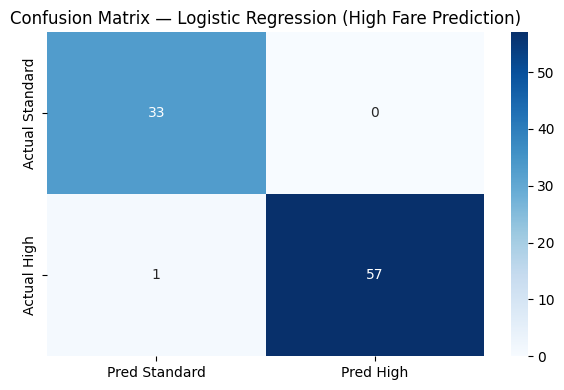

In [38]:
# ── 9.3 Confusion Matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y9_test, y9_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Standard', 'Pred High'],
            yticklabels=['Actual Standard', 'Actual High'])
plt.title("Confusion Matrix — Logistic Regression (High Fare Prediction)")
plt.tight_layout()
plt.show()

---
## Experiment 10 — K-Means Clustering

### Theory
Unlike supervised learning, clustering is **unsupervised** — there are no predefined labels.  
The algorithm discovers natural groupings in the data purely from the feature values.

**K-Means Algorithm**  
1. Randomly initialise K centroids  
2. Assign each point to its nearest centroid (Euclidean distance)  
3. Recompute centroids as the mean of all points in each cluster  
4. Repeat steps 2–3 until assignments stop changing  

Here K = 3 splits trips into three natural value tiers based on trip distance and fare amount:  
- **Short/cheap trips** (e.g. quick hops around Manhattan)  
- **Medium trips** (e.g. cross-town, airport shuttles)  
- **Long/expensive trips** (e.g. JFK or LaGuardia routes)

**Why visualise centroids?**  
Centroids represent the "average trip" in each cluster. Plotting them (marked with ✕) alongside the clusters helps you interpret what each group represents.


In [39]:
# ── 10.1 Cluster on Trip Distance & Fare Amount ──────────────────────────────
X10 = df_clean[['trip_distance', 'fare_amount']]

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean = df_clean.copy()
df_clean['cluster'] = kmeans.fit_predict(X10)

print("Cluster distribution:")
print(df_clean['cluster'].value_counts().sort_index())

Cluster distribution:
cluster
0    240
1     62
2    151
Name: count, dtype: int64


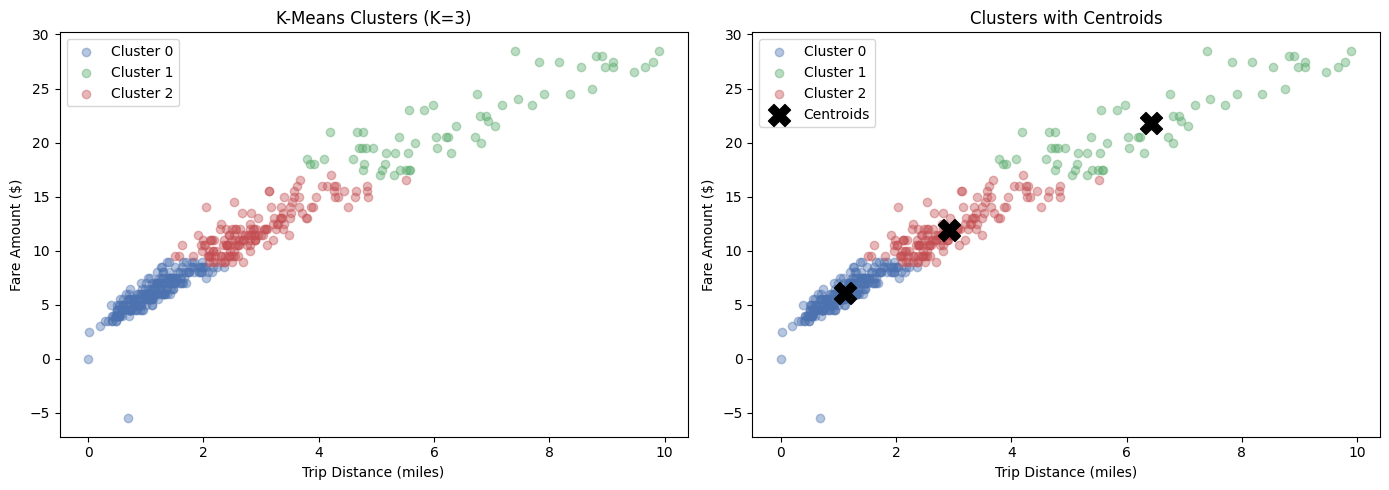

In [40]:
# ── 10.2 Visualise Clusters & Centroids ──────────────────────────────────────
centroids = kmeans.cluster_centers_
colors = ['#4C72B0', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Without centroids
for c in [0, 1, 2]:
    mask = df_clean['cluster'] == c
    axes[0].scatter(df_clean.loc[mask, 'trip_distance'],
                    df_clean.loc[mask, 'fare_amount'],
                    alpha=0.4, color=colors[c], label=f"Cluster {c}")
axes[0].set_xlabel("Trip Distance (miles)")
axes[0].set_ylabel("Fare Amount ($)")
axes[0].set_title("K-Means Clusters (K=3)")
axes[0].legend()

# With centroids
for c in [0, 1, 2]:
    mask = df_clean['cluster'] == c
    axes[1].scatter(df_clean.loc[mask, 'trip_distance'],
                    df_clean.loc[mask, 'fare_amount'],
                    alpha=0.4, color=colors[c], label=f"Cluster {c}")
axes[1].scatter(centroids[:, 0], centroids[:, 1],
                marker='X', s=250, c='black', zorder=5, label='Centroids')
axes[1].set_xlabel("Trip Distance (miles)")
axes[1].set_ylabel("Fare Amount ($)")
axes[1].set_title("Clusters with Centroids")
axes[1].legend()

plt.tight_layout()
plt.show()

In [41]:
# ── 10.3 Cluster Profiles ─────────────────────────────────────────────────────
print("Mean characteristics per cluster:")
df_clean.groupby('cluster')[['trip_distance', 'fare_amount', 'tip_amount', 'trip_duration_min']].mean().round(2)

Mean characteristics per cluster:


,trip_distance,fare_amount,tip_amount,trip_duration_min
cluster,,,,
0,1.11,6.08,1.01,5.65
1,6.42,21.81,3.19,21.37
2,2.92,11.96,1.79,12.81


---
## Experiment 11 — Big Data EDA with PySpark

### Theory
As datasets grow beyond single-machine memory (think millions of taxi rows — the full NYC TLC dataset has 1B+ rows), Pandas becomes a bottleneck.  
**Apache Spark** is a distributed computing framework that processes data in parallel across a cluster.

**PySpark** is the Python API for Spark. Key concepts:
- **SparkSession:** Entry point to all Spark functionality
- **DataFrame (Spark DF):** Distributed table, similar to a Pandas DataFrame but computed lazily across nodes
- **Schema inference:** Spark reads column types automatically (`inferSchema=True`)
- **Lazy evaluation:** Spark builds an execution plan but only runs it when `.show()`, `.collect()`, or `.count()` is called

In this experiment we replicate the EXP 1 EDA (info, summary, group analysis, filtering) using Spark to demonstrate the big-data equivalent workflow — the same code that would scale to the full 1B-row TLC dataset on a real cluster.

> **Note on Colab:** Spark runs on a single Colab machine here, not a real cluster — but the code is identical to what you'd run on a distributed environment.


In [42]:
# ── 11.1 Install & Start Spark ────────────────────────────────────────────────
try:
    from pyspark.sql import SparkSession
    print("PySpark found.")
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "pyspark", "-q"])
    from pyspark.sql import SparkSession
    print("PySpark installed and imported.")

spark = SparkSession.builder \
    .appName("NYCTaxiEDA") \
    .config("spark.sql.repl.eagerEval.enabled", True) \
    .getOrCreate()

print(f"Spark version: {spark.version}")

PySpark found.
Spark version: 4.0.2


In [43]:
# ── 11.2 Load Dataset into Spark ──────────────────────────────────────────────
# Save cleaned df to CSV first, then load into Spark
df_clean.to_csv("taxi_spark.csv", index=False)

spark_df = spark.read.csv("taxi_spark.csv", header=True, inferSchema=True)
print(f"Row count: {spark_df.count()}  |  Columns: {len(spark_df.columns)}")
spark_df.show(5)

Row count: 453  |  Columns: 24
+--------+--------------------+---------------------+---------------+-------------+------------------+------------------+----------+------------------+------------------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+------------------+-----------+----------------+----------+-------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|  pickup_longitude|   pickup_latitude|RatecodeID|store_and_fwd_flag| dropoff_longitude|  dropoff_latitude|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount| trip_duration_min|pickup_hour|pickup_dayofweek|pickup_day|cluster|
+--------+--------------------+---------------------+---------------+-------------+------------------+------------------+----------+------------------+------------------+------------------+------------+-----------+-----+-------+----------+------------+-------

In [44]:
# ── 11.3 Schema & Summary Statistics ─────────────────────────────────────────
print("Schema:")
spark_df.printSchema()

Schema:
root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: integer (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- pickup_longitude: double (nullable = true)
 |-- pickup_latitude: double (nullable = true)
 |-- RatecodeID: integer (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- dropoff_longitude: double (nullable = true)
 |-- dropoff_latitude: double (nullable = true)
 |-- payment_type: integer (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- trip_duration_min: double (nullable = true)
 |-- pickup_hour: integer (nullable = true)
 |-- pickup_dayof

In [45]:
print("Summary statistics (Spark describe):")
spark_df.describe(['fare_amount', 'trip_distance', 'tip_amount', 'trip_duration_min']).show()

Summary statistics (Spark describe):
+-------+------------------+------------------+------------------+------------------+
|summary|       fare_amount|     trip_distance|        tip_amount| trip_duration_min|
+-------+------------------+------------------+------------------+------------------+
|  count|               453|               453|               453|               453|
|   mean|10.193156732891833| 2.438874172185429|1.5667549668874174| 10.18465783664459|
| stddev| 5.764429525664608|1.9676570260554624| 1.526860195657276| 6.363798753430202|
|    min|              -5.5|               0.0|               0.0|              0.05|
|    max|              28.5|               9.9|              10.3|35.266666666666666|
+-------+------------------+------------------+------------------+------------------+



In [46]:
# ── 11.4 Group Analysis ───────────────────────────────────────────────────────
from pyspark.sql import functions as F

print("Average fare by Vendor:")
spark_df.groupBy("VendorID").agg(
    F.round(F.avg("fare_amount"), 2).alias("avg_fare"),
    F.count("*").alias("trip_count")
).show()

print("Average fare by Payment Type:")
spark_df.groupBy("payment_type").agg(
    F.round(F.avg("fare_amount"), 2).alias("avg_fare"),
    F.count("*").alias("trip_count")
).orderBy("avg_fare", ascending=False).show()

Average fare by Vendor:
+--------+--------+----------+
|VendorID|avg_fare|trip_count|
+--------+--------+----------+
|       1|   10.25|        62|
|       2|   10.18|       391|
+--------+--------+----------+

Average fare by Payment Type:
+------------+--------+----------+
|payment_type|avg_fare|trip_count|
+------------+--------+----------+
|           1|   10.29|       339|
|           2|    9.97|       111|
|           3|    7.33|         3|
+------------+--------+----------+



In [47]:
# ── 11.5 Filtered Query — High Value Trips ───────────────────────────────────
print("High-value trips (fare > $30, first 10):")
spark_df.filter(spark_df.fare_amount > 30).select(
    'VendorID', 'passenger_count', 'trip_distance',
    'fare_amount', 'tip_amount', 'trip_duration_min'
).show(10)

High-value trips (fare > $30, first 10):
+--------+---------------+-------------+-----------+----------+-----------------+
|VendorID|passenger_count|trip_distance|fare_amount|tip_amount|trip_duration_min|
+--------+---------------+-------------+-----------+----------+-----------------+
+--------+---------------+-------------+-----------+----------+-----------------+



In [48]:
# ── 11.6 Stop Spark Session ───────────────────────────────────────────────────
spark.stop()
print("Spark session stopped.")

Spark session stopped.


---
## 📋 Experiment Summary

| # | Experiment | Key Technique | Output |
|---|-----------|--------------|--------|
| 1 | Data Exploration & Cleaning | Median/Mode imputation, Datetime parsing, Deduplication | `df_cleaned` |
| 2 | Data Visualisation | Histograms, Boxplots, Bar charts, Scatter, Heatmap | Visual insights |
| 3 | Outlier Detection & Removal | IQR method, Z-Score method | `df_clean` |
| 4 | Feature Scaling | Min-Max Normalisation, Z-Score Standardisation | `df_norm`, `df_std` |
| 5 | Class Imbalance Handling | SMOTE over-sampling (payment type) | Balanced training set |
| 6 | Feature Selection + Regression | Linear Regression (all features → total_amount) | R² & MSE |
| 7 | Hypothesis Testing | Independent t-test (card vs cash fares) | p-value decision |
| 8 | Simple Linear Regression | 2-feature model (distance + duration → fare) | Interpretable coefficients |
| 9 | Binary Classification | Logistic Regression (high vs standard fare) | Accuracy, F1, Confusion matrix |
| 10 | Clustering | K-Means (K=3) on trip distance & fare | Cluster trip profiles |
| 11 | Big Data EDA | PySpark DataFrame operations | Distributed query results |
